In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
file1 = "world_happiness/2015.csv"
file2 = "world_happiness/2016.csv"
file3 = "world_happiness/2017.csv"
file4 = "world_happiness/2018.csv"
file5 = "world_happiness/2019.csv"
df_2015 = pd.read_csv(file1)
df_2016 = pd.read_csv(file2)
df_2017 = pd.read_csv(file3)
df_2018 = pd.read_csv(file4)
df_2019 = pd.read_csv(file5)

In [3]:
print(df_2015.dtypes)
print(df_2016.dtypes)
print(df_2017.dtypes)
print(df_2018.dtypes)
print(df_2019.dtypes)

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object
Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dy

In [4]:
print(df_2015.info)
print(df_2016.info)
print(df_2017.info)
print(df_2018.info)
print(df_2019.info)

<bound method DataFrame.info of          Country                           Region  Happiness Rank  \
0    Switzerland                   Western Europe               1   
1        Iceland                   Western Europe               2   
2        Denmark                   Western Europe               3   
3         Norway                   Western Europe               4   
4         Canada                    North America               5   
..           ...                              ...             ...   
153       Rwanda               Sub-Saharan Africa             154   
154        Benin               Sub-Saharan Africa             155   
155        Syria  Middle East and Northern Africa             156   
156      Burundi               Sub-Saharan Africa             157   
157         Togo               Sub-Saharan Africa             158   

     Happiness Score  Standard Error  Economy (GDP per Capita)   Family  \
0              7.587         0.03411                   1.39651  

In [5]:
print(df_2015.describe)
print(df_2016.describe)
print(df_2017.describe)
print(df_2018.describe)
print(df_2019.describe)

<bound method NDFrame.describe of          Country                           Region  Happiness Rank  \
0    Switzerland                   Western Europe               1   
1        Iceland                   Western Europe               2   
2        Denmark                   Western Europe               3   
3         Norway                   Western Europe               4   
4         Canada                    North America               5   
..           ...                              ...             ...   
153       Rwanda               Sub-Saharan Africa             154   
154        Benin               Sub-Saharan Africa             155   
155        Syria  Middle East and Northern Africa             156   
156      Burundi               Sub-Saharan Africa             157   
157         Togo               Sub-Saharan Africa             158   

     Happiness Score  Standard Error  Economy (GDP per Capita)   Family  \
0              7.587         0.03411                   1.39651

In [6]:

df_2015 = df_2015.rename(columns={
    'Country': 'Country',
    'Happiness Rank': 'Rank',
    'Happiness Score': 'Score',
    'Economy (GDP per Capita)': 'GDP',
    'Family': 'Support',
    'Health (Life Expectancy)': 'Health',
    'Freedom': 'Freedom',
    'Trust (Government Corruption)': 'Trust',
    'Generosity': 'Generosity',
    'Dystopia Residual': 'Dystopia'
})


df_2016 = df_2016.rename(columns={
    'Country': 'Country',
    'Happiness Rank': 'Rank',
    'Happiness Score': 'Score',
    'Economy (GDP per Capita)': 'GDP',
    'Family': 'Support',
    'Health (Life Expectancy)': 'Health',
    'Freedom': 'Freedom',
    'Trust (Government Corruption)': 'Trust',
    'Generosity': 'Generosity',
    'Dystopia Residual': 'Dystopia'
})


df_2017 = df_2017.rename(columns={
    'Country': 'Country',
    'Happiness.Rank': 'Rank',
    'Happiness.Score': 'Score',
    'Economy..GDP.per.Capita.': 'GDP',
    'Family': 'Support',
    'Health..Life.Expectancy.': 'Health',
    'Freedom': 'Freedom',
    'Trust..Government.Corruption.': 'Trust',
    'Generosity': 'Generosity',
    'Dystopia.Residual': 'Dystopia'
})


df_2018 = df_2018.rename(columns={
    'Country or region': 'Country',
    'Overall rank': 'Rank',
    'Score': 'Score',
    'GDP per capita': 'GDP',
    'Social support': 'Support',
    'Healthy life expectancy': 'Health',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust',
    'Generosity': 'Generosity'
})


df_2019 = df_2019.rename(columns={
    'Country or region': 'Country',
    'Overall rank': 'Rank',
    'Score': 'Score',
    'GDP per capita': 'GDP',
    'Social support': 'Support',
    'Healthy life expectancy': 'Health',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust',
    'Generosity': 'Generosity'
})

standard_cols = ['Country', 'Rank', 'Score', 'GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']

df_2015 = df_2015[standard_cols]
df_2016 = df_2016[standard_cols]
df_2017 = df_2017[standard_cols]
df_2018 = df_2018[standard_cols]
df_2019 = df_2019[standard_cols]

In [7]:
df_2018['Trust'] = df_2018['Trust'].fillna(0)
df_2015['Year'] = 2015
df_2016['Year'] = 2016
df_2017['Year'] = 2017
df_2018['Year'] = 2018
df_2019['Year'] = 2019
df_all = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019], ignore_index=True)
df_all.head()

,Country,Rank,Score,GDP,Support,Health,Freedom,Trust,Generosity,Year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [8]:
dfs = {
    '2015': df_2015[standard_cols],
    '2016': df_2016[standard_cols],
    '2017': df_2017[standard_cols],
    '2018': df_2018[standard_cols],
    '2019': df_2019[standard_cols],
}

for year, df in dfs.items():
    print(f"\n==== {year} ====")
    # nulls by column
    print("Nulls per column:")
    print(df.isna().sum())

    # zeros by column (numeric cols only)
    num_cols = df.select_dtypes(include=[np.number]).columns
    zero_counts = (df[num_cols] == 0).sum().reindex(standard_cols, fill_value=0)
    print("\nZeros per numeric column:")
    print(zero_counts)

    # rows with any zero in numeric cols
    rows_any_zero = (df[num_cols] == 0).any(axis=1).sum()
    print(f"\nRows with ANY zero in numeric columns: {rows_any_zero} / {len(df)}")


==== 2015 ====
Nulls per column:
Country       0
Rank          0
Score         0
GDP           0
Support       0
Health        0
Freedom       0
Trust         0
Generosity    0
dtype: int64

Zeros per numeric column:
Country       0
Rank          0
Score         0
GDP           1
Support       1
Health        1
Freedom       1
Trust         1
Generosity    1
dtype: int64

Rows with ANY zero in numeric columns: 6 / 158

==== 2016 ====
Nulls per column:
Country       0
Rank          0
Score         0
GDP           0
Support       0
Health        0
Freedom       0
Trust         0
Generosity    0
dtype: int64

Zeros per numeric column:
Country       0
Rank          0
Score         0
GDP           1
Support       1
Health        1
Freedom       1
Trust         1
Generosity    1
dtype: int64

Rows with ANY zero in numeric columns: 6 / 157

==== 2017 ====
Nulls per column:
Country       0
Rank          0
Score         0
GDP           0
Support       0
Health        0
Freedom       0
Trust   

In [9]:
def drop_zero_rows(df, numeric_cols, target_cols=None):
    """
    Removes rows where numeric columns have 0s.
    If target_cols is given, rows with 0 in those columns are always dropped.
    """
    mask = (df[numeric_cols] == 0).any(axis=1)
    if target_cols:
        mask |= (df[target_cols] == 0).any(axis=1)
    return df[~mask]

numeric_cols = ['Rank', 'Score', 'GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']
target_cols = ['Score', 'Rank', 'GDP', 'Support', 'Health', 'Trust', 'Generosity' ]  

df_2015 = drop_zero_rows(df_2015, numeric_cols, target_cols)
df_2016 = drop_zero_rows(df_2016, numeric_cols, target_cols)
df_2017 = drop_zero_rows(df_2017, numeric_cols, target_cols)
df_2018 = drop_zero_rows(df_2018, numeric_cols, target_cols)
df_2019 = drop_zero_rows(df_2019, numeric_cols, target_cols)

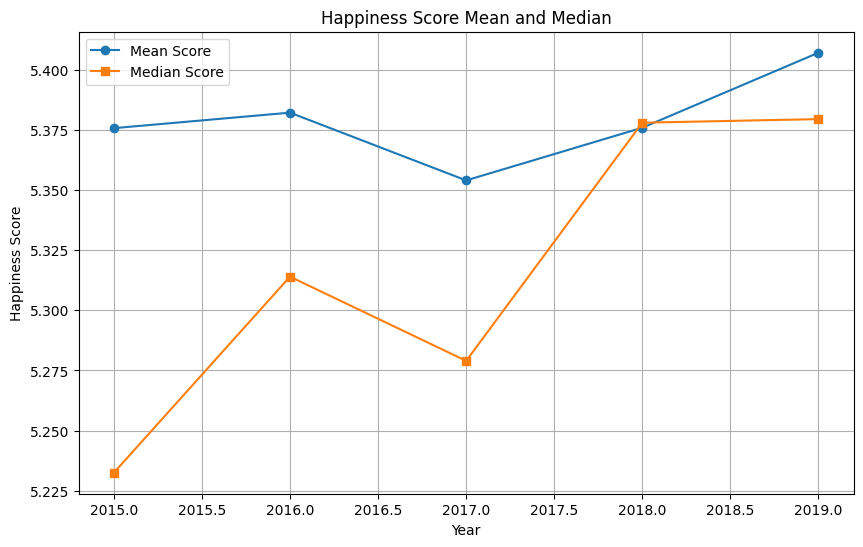

In [10]:
central_tendencies = df_all.groupby("Year")["Score"].agg(["mean", "median"]).reset_index()
plt.figure(figsize=(10, 6))
plt.plot(central_tendencies['Year'], central_tendencies['mean'], marker='o', label='Mean Score')
plt.plot(central_tendencies['Year'], central_tendencies['median'], marker='s', label='Median Score')
plt.title('Happiness Score Mean and Median')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.legend()
plt.grid(True)
plt.show()
#Although both the mean and median drop in 2017, there is still an overall increase in happiness score from 2015 to 2019.
#The increase in mean is not significant, but the increase in median is more apparent.

In [11]:
rank_features = df_all[['Country', 'Year', 'Rank']]
#Pivot so each year becomes a column, and rows are countries
rank_pivot = rank_features.pivot(index='Country',columns='Year',values='Rank')

#Drop rows with any missing years
rank_pivot = rank_pivot.dropna()
print(rank_pivot.head())
#Calculate ranking differences
rank_pivot['std_dev'] = rank_pivot.std(axis=1)          
rank_pivot['improvement'] = rank_pivot[2015] - rank_pivot[2019]

most_stable = rank_pivot.sort_values('std_dev').head(10)
most_improved = rank_pivot.sort_values('improvement', ascending=False).head(10)
print("Top 5 most stable ranking")
print(most_stable.head())
print("Top 5 most improved ranking")
print(most_improved.head())

Year          2015   2016   2017   2018   2019
Country                                       
Afghanistan  153.0  154.0  141.0  145.0  154.0
Albania       95.0  109.0  109.0  112.0  107.0
Algeria       68.0   38.0   53.0   84.0   88.0
Argentina     30.0   26.0   24.0   29.0   47.0
Armenia      127.0  121.0  121.0  129.0  116.0
Top 5 most stable ranking
Year         2015  2016  2017  2018  2019   std_dev  improvement
Country                                                         
New Zealand   9.0   8.0   8.0   8.0   8.0  0.447214          1.0
Australia    10.0   9.0  10.0  10.0  11.0  0.707107         -1.0
Iceland       2.0   3.0   3.0   4.0   4.0  0.836660         -2.0
Denmark       3.0   1.0   2.0   3.0   2.0  0.836660          1.0
Netherlands   7.0   7.0   6.0   6.0   5.0  0.836660          2.0
Top 5 most improved ranking
Year          2015   2016   2017   2018   2019    std_dev  improvement
Country                                                               
Benin        155.0  

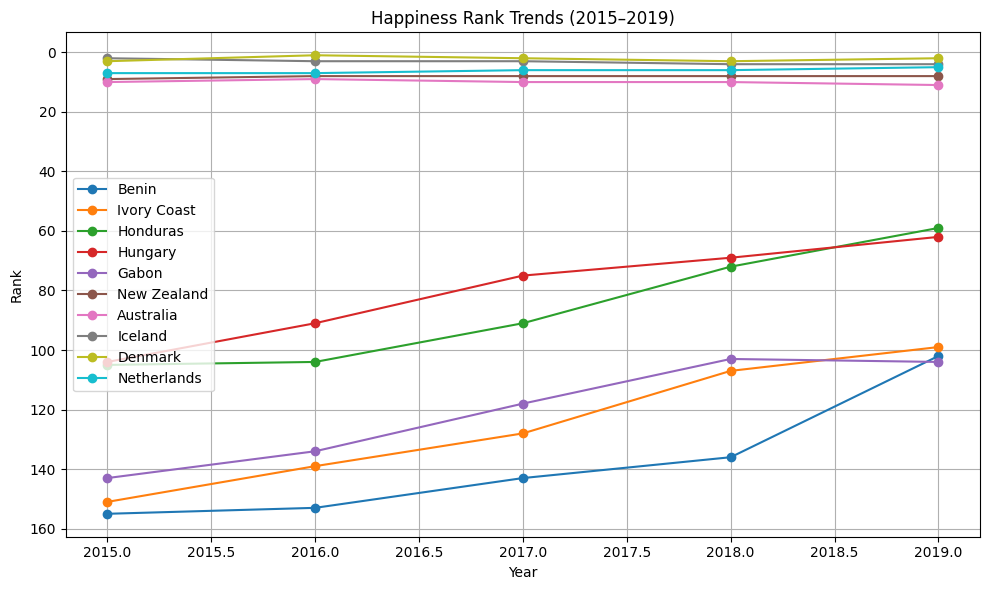

In [12]:
top_5_most_improved = most_improved.index[:5]
top_5_most_stable =  most_stable.index[:5]
plt.figure(figsize=(10, 6))
for country in top_5_most_improved:
    plt.plot(rank_pivot.columns[:-2], rank_pivot.loc[country].iloc[:-2], marker='o', label=country)

for country in top_5_most_stable:
    plt.plot(rank_pivot.columns[:-2], rank_pivot.loc[country].iloc[:-2], marker='o', label=country)

plt.gca().invert_yaxis()  # Rank 1 is best, so lower = better
plt.title('Happiness Rank Trends (2015–2019)')
plt.xlabel('Year')
plt.ylabel('Rank')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#The top 5 most stable country in terms of ranking are New Zealand, Australia, Iceland, Denmark, and Netherlands
#The top 5 most improved country in terms of ranking are Benin, Ivory Coast, Honduras, Hungary, and Gabon  

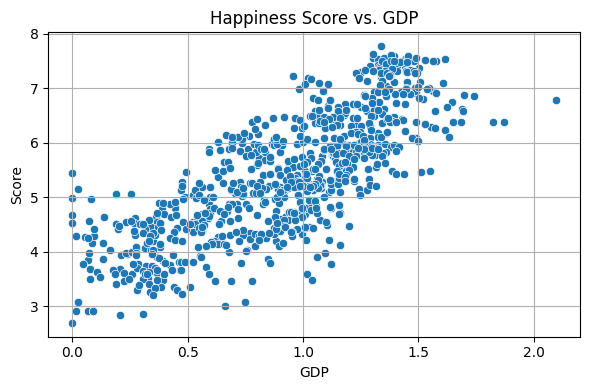

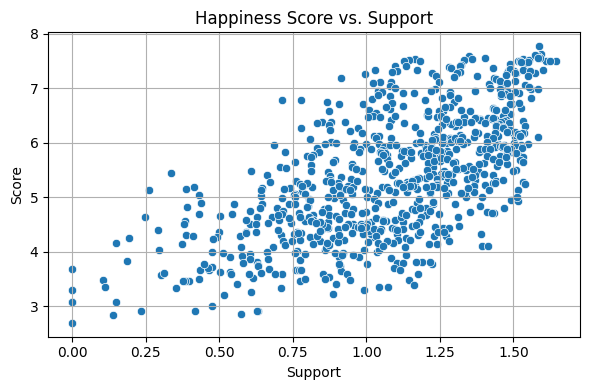

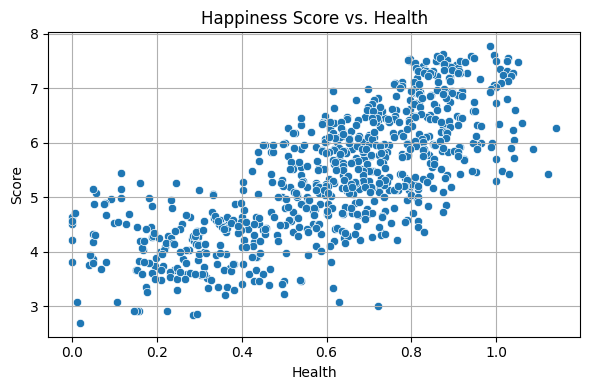

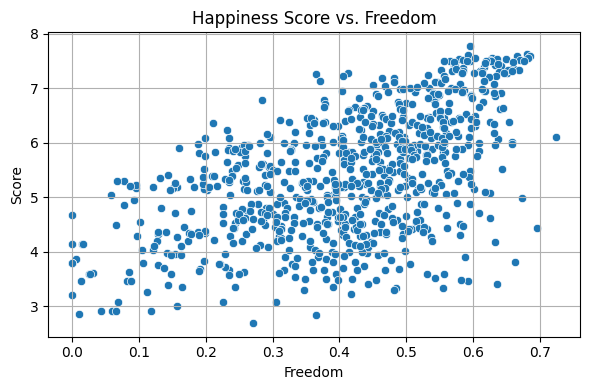

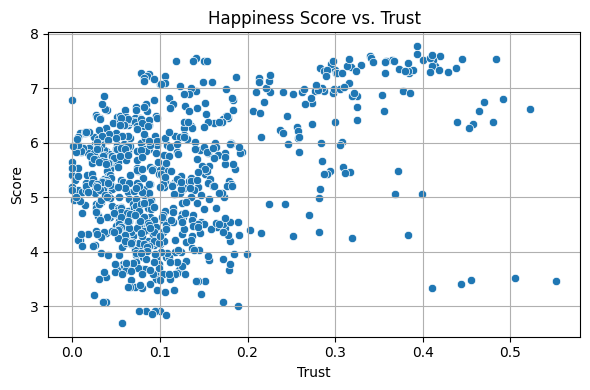

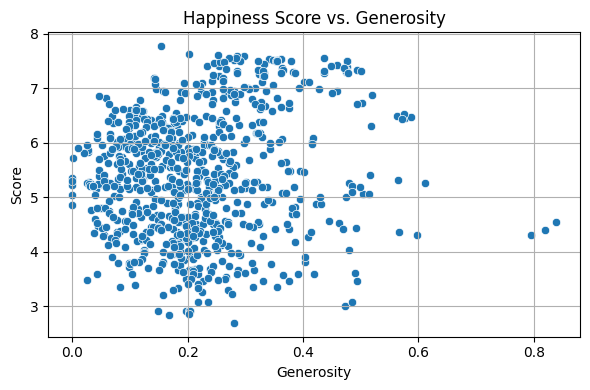

In [13]:
features = ['GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df_all, x=feature, y='Score')
    plt.title(f'Happiness Score vs. {feature}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
print('Correlation coefficients for each feature')
df_all[['Score', 'GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']].corr()['Score'].sort_values(ascending=False)

Correlation coefficients for each feature


Score         1.000000
GDP           0.789284
Health        0.742456
Support       0.648799
Freedom       0.551258
Trust         0.395792
Generosity    0.137578
Name: Score, dtype: float64

In [15]:
X = df_all[['GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']]
y = df_all['Score']

model = LinearRegression()
model.fit(X, y)

print('Linear coefficients for each feature')
pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

Linear coefficients for each feature


Freedom       1.481234
GDP           1.150354
Health        1.001636
Trust         0.842390
Support       0.639169
Generosity    0.595673
dtype: float64

In [16]:
#Features being used
features = ['GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']

#Training data:2015–2018
train_df = df_all[df_all['Year'] < 2019].copy()
X_train = train_df[features].values
y_train = train_df['Rank'].values

#Testing data:2019
test_df = df_all[df_all['Year'] == 2019].copy()
X_test = test_df[features].values
y_test = test_df['Rank'].values

#Add bias
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

#Compute coefficients using normal equation
beta = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

#Make predictions
y_pred = X_test_bias @ beta
mae = np.mean(np.abs(y_pred - y_test))
rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))

print("Coefficients:", beta)
print("MAE:", mae)
print("RMSE:", rmse)


Coefficients: [203.66730016 -45.73191225 -24.63594287 -45.76130168 -56.34481755
 -23.65884795 -17.29140629]
MAE: 17.709638004938668
RMSE: 23.01202798933775


In [17]:

countries_2019 = test_df['Country'].values
comparison_df = pd.DataFrame({
    'Country': countries_2019,
    'Actual Rank': y_test,
    'Predicted Rank': y_pred
})

comparison_df = comparison_df.sort_values('Actual Rank').reset_index(drop=True)
print(comparison_df)

                      Country  Actual Rank  Predicted Rank
0                     Finland            1       12.643629
1                     Denmark            2        8.675777
2                      Norway            3        2.871972
3                     Iceland            4       11.384705
4                 Netherlands            5       12.611872
..                        ...          ...             ...
151                    Rwanda          152       96.888554
152                  Tanzania          153      105.515143
153               Afghanistan          154      155.081005
154  Central African Republic          155      180.104210
155               South Sudan          156      155.798816

[156 rows x 3 columns]


KNN MAE: 14.893162393162392
KNN RMSE: 20.064887617420517
       Country  Actual Rank  Predicted Rank (KNN)
0      Finland            1                  5.00
1      Denmark            2                  5.67
2       Norway            3                 17.67
3      Iceland            4                 12.00
4  Netherlands            5                  7.67
Best k: 3
MAE: 14.893162393162392


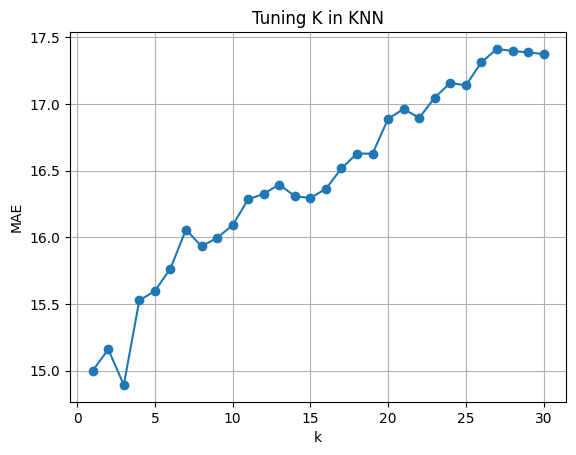

In [18]:

features = ['GDP', 'Support', 'Health', 'Freedom', 'Trust', 'Generosity']
k= 3
X_train = train_df[features].values
y_train = train_df['Rank'].values

X_test = test_df[features].values
y_test = test_df['Rank'].values
countries_2019 = test_df['Country'].values

#Compute distances from each test point to all training points
dists = cdist(X_test, X_train, metric='euclidean')  # shape: [n_test x n_train]

#For each test point, find the k nearest neighbors and average their ranks
y_pred_knn = np.zeros(X_test.shape[0])
for i in range(X_test.shape[0]):
    knn_indices = np.argsort(dists[i])[:k]
    y_pred_knn[i] = y_train[knn_indices].mean()

#Find the error
mae_knn = np.mean(np.abs(y_pred_knn - y_test))
rmse_knn = np.sqrt(np.mean((y_pred_knn - y_test) ** 2))

#Optimize k
print("KNN MAE:", mae_knn)
print("KNN RMSE:", rmse_knn)
comparison_knn = pd.DataFrame({
    'Country': countries_2019,
    'Actual Rank': y_test,
    'Predicted Rank (KNN)': y_pred_knn.round(2)
}).sort_values('Actual Rank').reset_index(drop=True)

print(comparison_knn.head())
errors = []
for k in range(1, 31):
    y_pred_k = []
    for i in range(X_test.shape[0]):
        knn_indices = np.argsort(dists[i])[:k]
        y_pred_k.append(y_train[knn_indices].mean())
    y_pred_k = np.array(y_pred_k)
    mae = np.mean(np.abs(y_pred_k - y_test))
    errors.append((k, mae))
best_k, best_mae = min(errors, key=lambda x: x[1])
print("Best k:", best_k)
print("MAE:", best_mae)
plt.plot([e[0] for e in errors], [e[1] for e in errors], marker='o')
plt.xlabel("k")
plt.ylabel("MAE")
plt.title("Tuning K in KNN")
plt.grid(True)
plt.show()

In [19]:
train_df.loc[:, 'HighHappiness'] = (train_df['Rank'] <= 75).astype(int)
test_df.loc[:, 'HighHappiness'] = (test_df['Rank'] <=75).astype(int)
X_train = train_df[features].values
y_train = train_df['HighHappiness'].values

X_test = test_df[features].values
y_test = test_df['HighHappiness'].values
countries_2019 = test_df['Country'].values

#Add bias
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

#Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Train logistic regression using gradient descent
def train_logistic_regression(X, y, lr=0.1, epochs=10000):
    beta = np.zeros(X.shape[1])
    for _ in range(epochs):
        z = X @ beta
        y_pred = sigmoid(z)
        gradient = X.T @ (y_pred - y) / X.shape[0]
        beta -= lr * gradient
    return beta

beta_logreg = train_logistic_regression(X_train_bias, y_train)

#Predict probabilities for test set
z_test = X_test_bias @ beta_logreg
probabilities = sigmoid(z_test)

#Rank by predicted probability
ranking_df = pd.DataFrame({
    'Country': countries_2019,
    'Probability of High Happiness': probabilities,
    'Actual Rank': test_df['Rank'].values,
    'Actual High Happiness': y_test
}).sort_values('Probability of High Happiness', ascending=False).reset_index(drop=True)

print(ranking_df.head())
predicted_rank_order = np.argsort(probabilities)[::-1]
actual_ranks = test_df.iloc[predicted_rank_order]['Rank'].values
ideal_rank = np.arange(1, len(probabilities)+1)
mae = np.mean(np.abs(actual_ranks - ideal_rank))
rmse = np.sqrt(np.mean((actual_ranks - ideal_rank)**2))

print("MAE:", mae)
print("RMSE:", rmse)

       Country  Probability of High Happiness  Actual Rank  \
0    Singapore                       0.997756           34   
1       Norway                       0.996386            3   
2   Luxembourg                       0.995945           14   
3  Switzerland                       0.995055            6   
4      Denmark                       0.994220            2   

   Actual High Happiness  
0                      1  
1                      1  
2                      1  
3                      1  
4                      1  
MAE: 15.91025641025641
RMSE: 21.15480184321378


In [20]:
y_train = train_df['Rank'].values
y_test = test_df['Rank'].values
# Train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

rf_results_df = pd.DataFrame({
    'Country': test_df['Country'].values,        
    'Actual Rank': y_test,
    'Predicted Rank (RF)': y_pred_rf.round(2)
})

rf_results_df = rf_results_df.sort_values('Actual Rank').reset_index(drop=True)

# Print the top 10
print(rf_results_df.head(10))
#optimize parameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

best_mae = float('inf')
best_params = None

for n in param_grid['n_estimators']:
    for d in param_grid['max_depth']:
        for f in param_grid['max_features']:
            rf = RandomForestRegressor(
                n_estimators=n,
                max_depth=d,
                max_features=f,
                random_state=42
            )
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            print(f"n={n}, depth={d}, features={f} → MAE={mae:.2f}, RMSE={rmse:.2f}")

            if mae < best_mae:
                best_mae = mae
                best_rmse = rmse
                best_params = (n, d, f)

print("Best params:")
print(f"n_estimators={best_params[0]}, max_depth={best_params[1]}, max_features={best_params[2]}")
print(f"Best MAE: {best_mae:.2f}, Best RMSE: {best_rmse:.2f}")

Random Forest MAE: 19.773141025641028
Random Forest RMSE: 24.535272137193708
       Country  Actual Rank  Predicted Rank (RF)
0      Finland            1                38.62
1      Denmark            2                35.78
2       Norway            3                42.55
3      Iceland            4                46.72
4  Netherlands            5                41.08
5  Switzerland            6                44.41
6       Sweden            7                37.62
7  New Zealand            8                43.53
8       Canada            9                46.94
9      Austria           10                52.31
n=100, depth=None, features=sqrt → MAE=18.61, RMSE=22.81
n=100, depth=None, features=log2 → MAE=18.61, RMSE=22.81
n=100, depth=5, features=sqrt → MAE=19.18, RMSE=23.45
n=100, depth=5, features=log2 → MAE=19.18, RMSE=23.45
n=100, depth=10, features=sqrt → MAE=18.53, RMSE=22.78
n=100, depth=10, features=log2 → MAE=18.53, RMSE=22.78
n=100, depth=20, features=sqrt → MAE=18.46, RMSE=22.

In [21]:


#Train using gradient boosting regressor libaray
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05)
gb.fit(X_train, y_train)

#predict and evaluation
y_pred_gb = gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)
results_df = pd.DataFrame({
    'Country': test_df['Country'].values, 
    'Actual Rank': y_test,
    'Predicted Rank (GB)': y_pred_gb.round(2)
})

# Sort by actual or predicted rank
results_df = results_df.sort_values('Actual Rank').reset_index(drop=True)

# Print first few rows
print(results_df.head(10))
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

#Optimize
best_mae = float('inf')
best_params = None

for n in param_grid['n_estimators']:
    for lr in param_grid['learning_rate']:
        for d in param_grid['max_depth']:
            gb = GradientBoostingRegressor(
                n_estimators=n,
                learning_rate=lr,
                max_depth=d,
                random_state=42
            )
            gb.fit(X_train, y_train)
            y_pred = gb.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            print(f"n={n}, lr={lr}, depth={d} → MAE={mae:.2f}, RMSE={rmse:.2f}")

            if mae < best_mae:
                best_mae = mae
                best_rmse = rmse
                best_params = (n, lr, d)

print("Best params:")
print(f"n_estimators={best_params[0]}, learning_rate={best_params[1]}, max_depth={best_params[2]}")
print(f"Best MAE: {best_mae:.2f}, Best RMSE: {best_rmse:.2f}")

Gradient Boosting MAE: 20.33914352888174
Gradient Boosting RMSE: 24.897614284740357
       Country  Actual Rank  Predicted Rank (GB)
0      Finland            1                37.68
1      Denmark            2                33.48
2       Norway            3                45.69
3      Iceland            4                39.61
4  Netherlands            5                38.86
5  Switzerland            6                46.21
6       Sweden            7                34.00
7  New Zealand            8                43.96
8       Canada            9                46.67
9      Austria           10                50.09
n=100, lr=0.01, depth=2 → MAE=26.44, RMSE=31.20
n=100, lr=0.01, depth=3 → MAE=25.07, RMSE=29.83
n=100, lr=0.01, depth=4 → MAE=24.92, RMSE=29.68
n=100, lr=0.05, depth=2 → MAE=19.86, RMSE=24.03
n=100, lr=0.05, depth=3 → MAE=20.32, RMSE=24.87
n=100, lr=0.05, depth=4 → MAE=20.62, RMSE=25.19
n=100, lr=0.1, depth=2 → MAE=20.77, RMSE=25.22
n=100, lr=0.1, depth=3 → MAE=20.77, RMSE=2

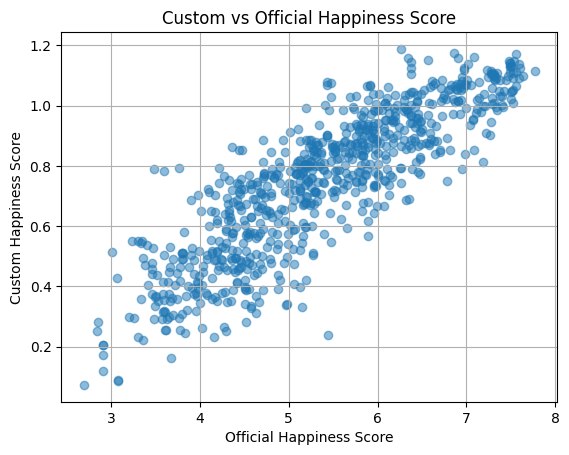

,Score,CustomHappiness
Score,1.000000,0.860394
CustomHappiness,0.860394,1.000000


In [22]:
#Formula to predict happiness by assinging weights
df_all['CustomHappiness'] = (
    0.2 * df_all['Support'] +
    0.25 * df_all['Freedom'] +
    0.3 * df_all['GDP'] +
    0.25 * df_all['Health']
)

plt.scatter(df_all['Score'], df_all['CustomHappiness'], alpha=0.5)
plt.xlabel('Official Happiness Score')
plt.ylabel('Custom Happiness Score')
plt.title('Custom vs Official Happiness Score')
plt.grid(True)
plt.show()

df_all[['Score', 'CustomHappiness']].corr()